In [2]:
from sklearn.model_selection import cross_val_score
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import ast

seed = 402

In [3]:
def paint_results(y_test, y_pred, order = True):
  # Grafica de la predicción y la realidad
  linespace = np.linspace(0, 1, y_pred.size)
  if order:
    # Ordena los pares test pred para que se vean mejor
    y_test, y_pred = zip(*sorted(zip(y_test, y_pred)))

  plt.plot(linespace, y_test, label="Real", marker="o")
  plt.plot(linespace, y_pred, label="Predicción", marker="x")
  plt.legend()
  plt.title("Real vs Predicción")
  plt.show()
  
def paint_real_vs_pred(y_test, y_pred):
  # Grafica de la predicción y la realidad
  plt.scatter(y_test, y_pred, marker="o")
  plt.xlabel("Real")
  plt.ylabel("Predicción")
  plt.title("Real vs Predicción")
  plt.show()
  # linealidad
  pearson = pearsonr(y_test, y_pred)[0]
  spearman = spearmanr(y_test, y_pred)[0]
  print(f"Pearson: {pearson:.4f}, Spearman: {spearman:.4f}")

In [5]:
model = XGBRegressor()
model.load_model("xgboost_model_28-11-25.json")

In [111]:
df = pd.read_csv("./results_transformed_2376.csv")
df["real_codification"] = df.real_codification.apply(ast.literal_eval)

X = np.stack(df["real_codification"].values)
Y = df["val_iou"].to_numpy(dtype=float)


# Modelo base

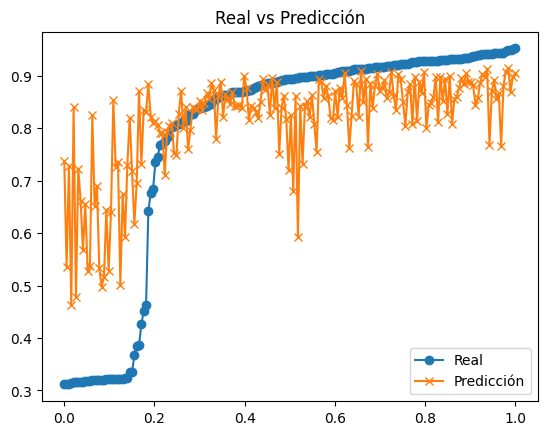

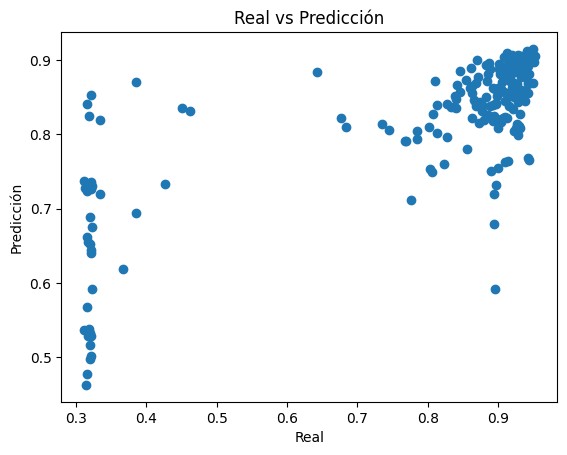

Pearson: 0.7532, Spearman: 0.6461
MAE:  0.10671080851165701


In [10]:
from sklearn.model_selection import train_test_split

# 1. Lee tus datos
df = pd.read_csv("./results_transformed_2376.csv")
X = df["real_codification"].apply(ast.literal_eval).apply(pd.Series)
Y = df["val_iou"]

# 2. Split train/valid (fijo)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, Y, test_size=0.2, random_state=seed
)

y_pred = model.predict(X_valid)

paint_results(y_valid, y_pred, order=True)
paint_real_vs_pred(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("MAE: ", mae)

Validación cruzada con Scikit-learn

In [115]:
scores = cross_val_score(model, X, Y, cv=10, scoring="neg_mean_absolute_error")  # 8-fold CV
mae_scores = -scores
print("MAE por fold:", mae_scores)
print("MAE promedio:", mae_scores.mean())


MAE por fold: [0.10854858 0.09241527 0.07798354 0.09284484 0.10505177 0.09228879
 0.0870181  0.0795216  0.11026866 0.09827945]
MAE promedio: 0.09442205958606043


Validación cruzada manual

In [114]:
kf = KFold(n_splits=10, shuffle=True, random_state=seed)
model_params = model.get_params()

errors = []
pearsons = []
spearmans = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]

    fold_model = XGBRegressor(**model_params)
    fold_model.fit(X_train, y_train)
    preds = fold_model.predict(X_test)

    errors.append(mean_absolute_error(y_test, preds))
    pearsons.append(pearsonr(y_test, preds)[0])
    spearmans.append(spearmanr(y_test, preds)[0])
    
    #paint_results(y_test, preds, order=True)
    #paint_real_vs_pred(y_test, preds)

print("MAE por fold:", errors)
print("MAE promedio:", np.mean(errors))
print("Pearson promedio:", np.mean(pearsons))
print("Spearman promedio:", np.mean(spearmans))


MAE por fold: [0.10823240805532514, 0.09427799145175828, 0.09537242073373696, 0.09990027455222567, 0.09556240652435018, 0.08096827620390763, 0.09262266206167818, 0.08737008823561915, 0.11747487741954547, 0.09665532070132056]
MAE promedio: 0.09684367259394672
Pearson promedio: 0.5304044473624641
Spearman promedio: 0.5112034504523458


# Probando la predicción aleatoria

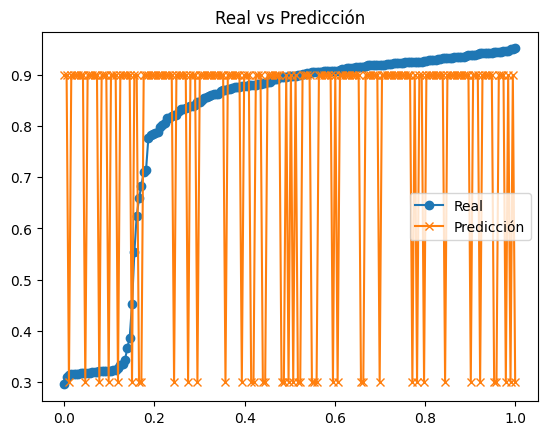

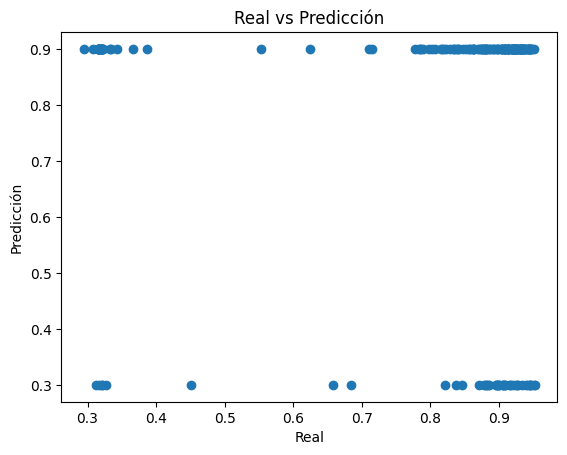

Pearson: -0.0295, Spearman: -0.0400
MAE:  0.20959832974520742


In [5]:
def sub(cromosoma):
    import random

    return random.choices([0.3, 0.9], weights=[0.2, 0.8], k=1)
  
from sklearn.model_selection import train_test_split

# 1. Lee tus datos
df = pd.read_csv("./results_transformed_2376.csv")
df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
X = df["real_codification"].apply(ast.literal_eval).apply(pd.Series)
Y = df["val_iou"]

# 2. Split train/valid (fijo)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, Y, test_size=0.2, random_state=seed
)

# random prediction
y_pred = [sub(cromosoma) for cromosoma in X_valid.values]
y_pred = np.array(y_pred).squeeze()

paint_results(y_valid, y_pred, order=True)
paint_real_vs_pred(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("MAE: ", mae)